# True-Core vs Reco-Core Points Compare

这个 notebook 对比两个 run：

1. `theta_truecore_points_edge0_2733`: points 由真实芯位 `(mc_xc, mc_yc)` 中心化
2. `no_core_cut_2724`: points 由重建芯位 `(xc, yc)` 中心化（旧对照 run）

目标：

- 先核对两组实验是否可以作为合理对照
- 再用 `preds.npz` 中的 `logE_true`、`logE_pred`、`mc_weight` 重新计算并叠加两条 weighted 曲线
- 输出三张对比图：`resolution_weighted`、`bias_weighted`、`logRMS_weighted`


## 1. 环境准备

这一格设置项目根目录、输出目录，并导入当前项目里与 weighted 曲线一致的统计函数。

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/server/projects/energy_reconstruction')
NOTEBOOK_DIR = PROJECT_ROOT / 'notebook'
OUTPUT_DIR = NOTEBOOK_DIR / 'generated' / 'truecore_vs_recocore_points_compare_2733_2724'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.utils import _weighted_mean, _weighted_std, _weighted_rms

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR   =', OUTPUT_DIR)


PROJECT_ROOT = /home/server/projects/energy_reconstruction
OUTPUT_DIR   = /home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724


## 2. 定义两个实验目录并检查结果文件

这里绑定两个 run，并确认 notebook 后续会读取的文件都存在。

In [2]:
RUNS = {
    'truecore': {
        'run_name': 'theta_truecore_points_edge0_2733',
        'display': 'true core points',
        'point_center': 'mc_xc, mc_yc',
    },
    'reco': {
        'run_name': 'no_core_cut_2724',
        'display': 'reco core points',
        'point_center': 'xc, yc',
    },
}

RESULTS = {}
for key, item in RUNS.items():
    run_dir = PROJECT_ROOT / 'runs' / item['run_name']
    fig_dir = run_dir / 'fig'
    config_path = run_dir / 'config.json'
    metrics_path = fig_dir / 'metrics.json'
    preds_path = fig_dir / 'preds.npz'
    train_stats_path = run_dir / 'dataset_train_stats.json'
    test_stats_path = run_dir / 'dataset_test_stats.json'

    assert run_dir.exists(), f'Missing run dir: {run_dir}'
    assert config_path.exists(), f'Missing config: {config_path}'
    assert metrics_path.exists(), f'Missing metrics: {metrics_path}'
    assert preds_path.exists(), f'Missing preds: {preds_path}'
    assert train_stats_path.exists(), f'Missing train stats: {train_stats_path}'
    assert test_stats_path.exists(), f'Missing test stats: {test_stats_path}'

    RESULTS[key] = {
        'display': item['display'],
        'point_center': item['point_center'],
        'run_dir': run_dir,
        'config_path': config_path,
        'metrics_path': metrics_path,
        'preds_path': preds_path,
        'train_stats_path': train_stats_path,
        'test_stats_path': test_stats_path,
    }

for key, item in RESULTS.items():
    print(f"{key:8s} -> {item['run_dir']}")
    print(f"  config      : {item['config_path']}")
    print(f"  metrics     : {item['metrics_path']}")
    print(f"  preds       : {item['preds_path']}")
    print(f"  train stats : {item['train_stats_path']}")
    print(f"  test stats  : {item['test_stats_path']}")


truecore -> /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733
  config      : /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733/config.json
  metrics     : /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733/fig/metrics.json
  preds       : /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733/fig/preds.npz
  train stats : /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733/dataset_train_stats.json
  test stats  : /home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733/dataset_test_stats.json
reco     -> /home/server/projects/energy_reconstruction/runs/no_core_cut_2724
  config      : /home/server/projects/energy_reconstruction/runs/no_core_cut_2724/config.json
  metrics     : /home/server/projects/energy_reconstruction/runs/no_core_cut_2724/fig/metrics.json
  preds       : /home/server/projects/energy_reconstr

## 3. 读取 `config.json`、`metrics.json`、`preds.npz` 和 dataset stats

这一步完全从 run 目录自动读取，不手工抄数据。

In [3]:
loaded = {}

for key, item in RESULTS.items():
    with open(item['config_path'], 'r') as f:
        config = json.load(f)
    with open(item['metrics_path'], 'r') as f:
        metrics = json.load(f)
    with open(item['train_stats_path'], 'r') as f:
        train_stats = json.load(f)
    with open(item['test_stats_path'], 'r') as f:
        test_stats = json.load(f)
    preds = np.load(item['preds_path'])

    loaded[key] = {
        'display': item['display'],
        'point_center': item['point_center'],
        'config': config,
        'metrics': metrics,
        'train_stats': train_stats,
        'test_stats': test_stats,
        'logE_true': preds['logE_true'].astype(np.float64),
        'logE_pred': preds['logE_pred'].astype(np.float64),
        'mc_weight': preds['mc_weight'].astype(np.float64),
    }

for key, item in loaded.items():
    print(item['display'])
    print('  point center:', item['point_center'])
    print('  n eval      :', item['metrics']['n'])
    print('  w_log_sigma :', item['metrics']['w_log_sigma'])
    print('  w_log_rmse  :', item['metrics']['w_log_rmse'])
    print('  w_log_bias  :', item['metrics']['w_log_bias'])


true core points
  point center: mc_xc, mc_yc
  n eval      : 667023
  w_log_sigma : 0.2042234550107232
  w_log_rmse  : 0.2063800005227924
  w_log_bias  : -0.029757103913426466
reco core points
  point center: xc, yc
  n eval      : 668231
  w_log_sigma : 0.20180263828301628
  w_log_rmse  : 0.20198704822217678
  w_log_bias  : -0.00862918664288414


## 4. 检查实验一致性

这里先比较关键训练参数，再列出需要在结论中注明的差异项。

In [4]:
compare_keys = [
    'root_path', 'n_files', 'epochs', 'batch_size', 'max_points', 'num_workers', 'io_workers',
    'norm_mode', 'sample_mode', 'Emin', 'Emax', 'dcedge_min', 'theta_max_deg', 'dangle_max_deg',
    'pinc_max', 'use_core_box', 'core_box', 'vqsamp_ratio_min', 'theta_embed_dim',
    'theta_embed_dropout', 'loss_mode', 'huber_delta', 'rel_delta', 'rel_squared',
    'eval_space', 'save_arrays', 'seed', 'test_size', 'val_size', 'lr', 'patience',
    'min_delta', 'grad_clip', 'bins_hist', 'min_count', 'max_weight'
]

diff_rows = []
for key in compare_keys:
    a = loaded['truecore']['config'].get(key)
    b = loaded['reco']['config'].get(key)
    if a != b:
        diff_rows.append((key, a, b))

print('Comparable config diffs:')
if diff_rows:
    for key, a, b in diff_rows:
        print(f'  {key}: truecore={a!r} | reco={b!r}')
else:
    print('  None')

meta_only_diffs = []
all_keys = sorted(set(loaded['truecore']['config']) | set(loaded['reco']['config']))
for key in all_keys:
    a = loaded['truecore']['config'].get(key, '<MISSING>')
    b = loaded['reco']['config'].get(key, '<MISSING>')
    if a != b and key not in compare_keys:
        meta_only_diffs.append((key, a, b))

print('\nOther config-schema / bookkeeping diffs:')
for key, a, b in meta_only_diffs:
    print(f'  {key}: truecore={a!r} | reco={b!r}')

print('\nDataset stats notes:')
print('  truecore train point_center =', loaded['truecore']['train_stats'].get('point_center'))
print('  reco train point_center     =', loaded['reco']['train_stats'].get('point_center', '<not recorded in old run>'))
print('  truecore test n_fail        =', loaded['truecore']['test_stats']['files']['n_fail'])
print('  reco test n_fail            =', loaded['reco']['test_stats']['files']['n_fail'])

is_reasonable_control = (len(diff_rows) == 0)
print('\nReasonable control by training settings:', is_reasonable_control)
print('Caveat: old reco-core run predates explicit point-center metadata and has one failed test file.')


Comparable config diffs:
  None

Other config-schema / bookkeeping diffs:
  eval_fitstat_equals: truecore=None | reco='<MISSING>'
  eval_require_fitstat0: truecore=None | reco='<MISSING>'
  fitstat_equals: truecore=0 | reco='<MISSING>'
  require_fitstat0: truecore=True | reco='<MISSING>'
  run_dir: truecore='/home/server/projects/energy_reconstruction/runs/theta_truecore_points_edge0_2733' | reco='/home/server/projects/energy_reconstruction/runs/no_core_cut_2724'
  tag: truecore='theta_truecore_points_edge0' | reco='no_core_cut'

Dataset stats notes:
  truecore train point_center = {'x': 'mc_xc', 'y': 'mc_yc'}
  reco train point_center     = <not recorded in old run>
  truecore test n_fail        = 0
  reco test n_fail            = 1

Reasonable control by training settings: True
Caveat: old reco-core run predates explicit point-center metadata and has one failed test file.


## 5. 用共享 true-energy bins 重算三条 weighted 曲线

这里复用 `src/common.utils` 相同的加权统计口径：

- `bias_weighted`: 每个 true-energy bin 内的加权平均残差 `logE_pred - logE_true`
- `resolution_weighted`: 每个 true-energy bin 内的加权 `std(logE_pred)`
- `logRMS_weighted`: 每个 true-energy bin 内的加权 RMS 残差

为了保证两组结果能直接叠图，这里使用两组样本共同的 true-energy 范围构造统一 bin edges。

In [5]:
def compute_weighted_curves(log_true, log_pred, weights, bin_edges):
    mask = (
        np.isfinite(log_true)
        & np.isfinite(log_pred)
        & np.isfinite(weights)
        & (weights > 0)
    )

    log_true = log_true[mask]
    log_pred = log_pred[mask]
    weights = weights[mask]

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bias = []
    resolution = []
    log_rms = []

    for i in range(len(bin_edges) - 1):
        m = (log_true >= bin_edges[i]) & (log_true < bin_edges[i + 1])
        if m.sum() > 10:
            residual = log_pred[m] - log_true[m]
            w = weights[m]
            bias.append(float(_weighted_mean(residual, w)))
            resolution.append(float(_weighted_std(log_pred[m], w)))
            log_rms.append(float(_weighted_rms(residual, w)))
        else:
            bias.append(np.nan)
            resolution.append(np.nan)
            log_rms.append(np.nan)

    return {
        'bin_centers': centers,
        'bias': np.asarray(bias, dtype=np.float64),
        'resolution': np.asarray(resolution, dtype=np.float64),
        'log_rms': np.asarray(log_rms, dtype=np.float64),
    }

combined_true = np.concatenate([
    loaded['truecore']['logE_true'][np.isfinite(loaded['truecore']['logE_true'])],
    loaded['reco']['logE_true'][np.isfinite(loaded['reco']['logE_true'])],
])
bin_edges = np.linspace(combined_true.min(), combined_true.max(), 21)

curves = {}
for key, item in loaded.items():
    curves[key] = compute_weighted_curves(
        item['logE_true'],
        item['logE_pred'],
        item['mc_weight'],
        bin_edges,
    )
    print(item['display'], 'valid bins =', np.isfinite(curves[key]['bias']).sum())


true core points valid bins = 20


reco core points valid bins = 20


## 6. 定义统一绘图函数

三张对比图复用同一套颜色、线型和图例格式。

In [6]:
plot_order = ['truecore', 'reco']
colors = {
    'truecore': '#1f77b4',
    'reco': '#d62728',
}
markers = {
    'truecore': 'o',
    'reco': 's',
}

def plot_compare(metric_key, ylabel, title, filename, draw_zero=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for key in plot_order:
        item = loaded[key]
        curve = curves[key]
        ax.plot(
            curve['bin_centers'],
            curve[metric_key],
            marker=markers[key],
            color=colors[key],
            linewidth=2,
            markersize=5,
            label=item['display'],
        )

    if draw_zero:
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)

    ax.set_xlabel(r'True Energy $\log_{10}(E/\mathrm{GeV})$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)

    return out_path


## 7. 画 `resolution_weighted` 对比图

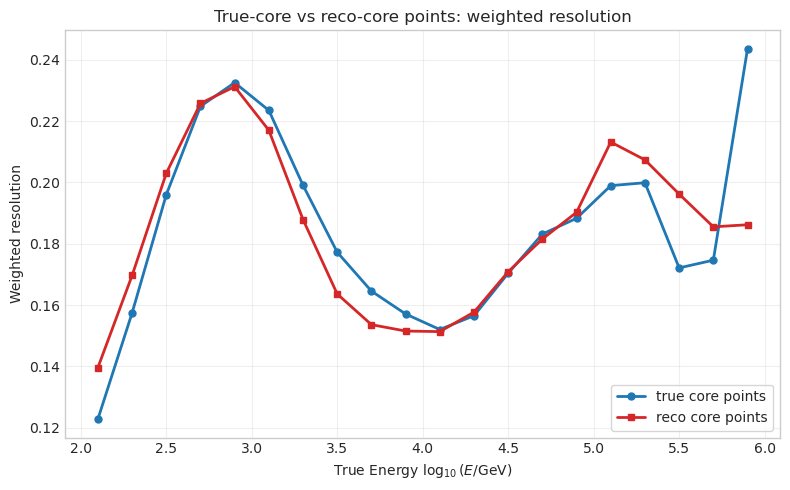

saved: /home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/resolution_weighted_true_vs_reco_core_points.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/resolution_weighted_true_vs_reco_core_points.png')

In [7]:
resolution_path = plot_compare(
    metric_key='resolution',
    ylabel='Weighted resolution',
    title='True-core vs reco-core points: weighted resolution',
    filename='resolution_weighted_true_vs_reco_core_points.png',
)
resolution_path


## 8. 画 `bias_weighted` 对比图

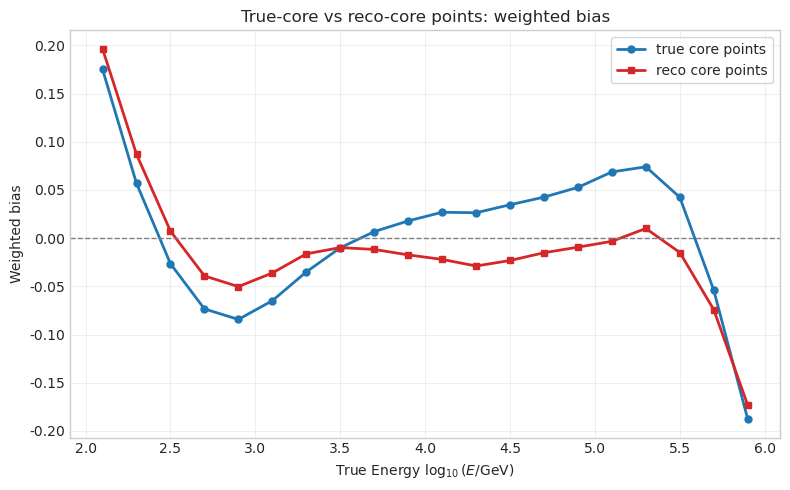

saved: /home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/bias_weighted_true_vs_reco_core_points.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/bias_weighted_true_vs_reco_core_points.png')

In [8]:
bias_path = plot_compare(
    metric_key='bias',
    ylabel='Weighted bias',
    title='True-core vs reco-core points: weighted bias',
    filename='bias_weighted_true_vs_reco_core_points.png',
    draw_zero=True,
)
bias_path


## 9. 画 `logRMS_weighted` 对比图

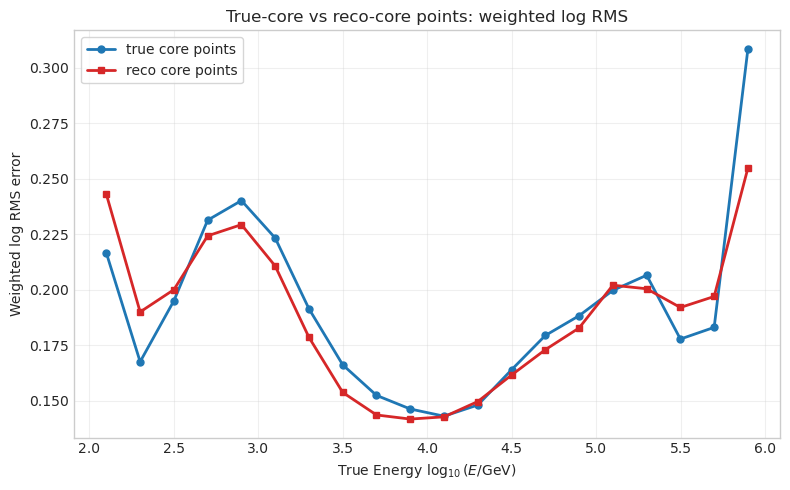

saved: /home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/logRMS_weighted_true_vs_reco_core_points.png


PosixPath('/home/server/projects/energy_reconstruction/notebook/generated/truecore_vs_recocore_points_compare_2733_2724/logRMS_weighted_true_vs_reco_core_points.png')

In [9]:
logrms_path = plot_compare(
    metric_key='log_rms',
    ylabel='Weighted log RMS error',
    title='True-core vs reco-core points: weighted log RMS',
    filename='logRMS_weighted_true_vs_reco_core_points.png',
)
logrms_path


## 10. 小结

如果上面的 `compare_keys` 没有差异，那么按训练设置可以把这两组结果视作一个合理的主对照；
但这里仍需注明两个 caveat：

- 旧 reco-core run 的 `config.json` 没显式记录 `fitstat` 字段，属于 run metadata schema 差异
- 旧 reco-core run 的 `dataset_test_stats.json` 记录了 `n_fail = 1`

因此它们是**合理但不是完全无保留的严格对照**。